Definition of Autoencoder

An Autoencoder is an unsupervised neural network that learns to compress input data into a lower-dimensional latent representation and reconstruct the original input from that representation.

It consists of:

Encoder → Compresses input

Decoder → Reconstructs input

The model is trained by minimizing reconstruction error:

𝐿
=
∣
∣
𝑥
−
𝑥
^
∣
∣
2
L=∣∣x−
x
^
∣∣
2

Where:

𝑥
x = original input

𝑥
^
x
^
 = reconstructed output

Architecture of Autoencoder
🔹 Basic Structure
Input (x)
   ↓
Encoder
   ↓
Latent Space (z)
   ↓
Decoder
   ↓
Reconstructed Output (x̂)
🔹 Mathematical Form
Encoder:
𝑧
=
𝑓
(
𝑥
)
z=f(x)
Decoder:
𝑥
^
=
𝑔
(
𝑧
)
x
^
=g(z)

Goal:

𝑥
^
≈
𝑥
x
^
≈x
🔹 Layer Architecture (Example for Images)
Layer	Purpose
Input Layer	784 (28×28 MNIST)
Hidden Layer	256
Latent Layer	64 (compressed representation)
Hidden Layer	256
Output Layer	784

Simple Application: Image Reconstruction (MNIST)

Step 1: Install & Import

In [1]:
!pip install torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Step 2: Load Dataset

In [3]:
transform = transforms.ToTensor()

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.17MB/s]


Step 3: Define Autoencoder

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        return x_reconstructed

Step 4: Initialize Model

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Step 5: Train the Autoencoder

In [6]:
epochs = 5

for epoch in range(epochs):
    for images, _ in dataloader:

        images = images.view(-1, 784).to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.4f}")

Epoch [1/5] Loss: 0.0195
Epoch [2/5] Loss: 0.0106
Epoch [3/5] Loss: 0.0095
Epoch [4/5] Loss: 0.0071
Epoch [5/5] Loss: 0.0057


Visualize Reconstruction

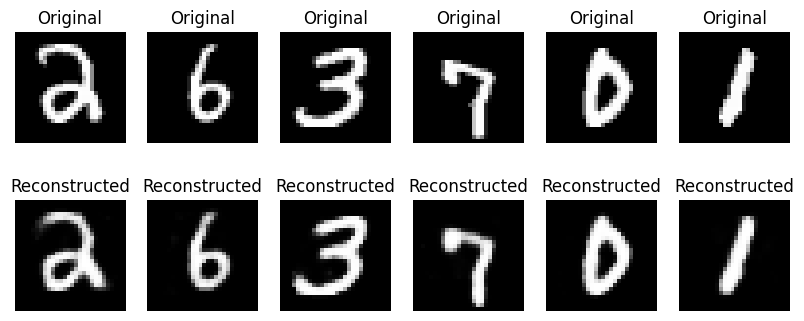

In [7]:
with torch.no_grad():
    images, _ = next(iter(dataloader))
    images = images.view(-1, 784).to(device)

    reconstructed = model(images)

    images = images.view(-1, 28, 28).cpu()
    reconstructed = reconstructed.view(-1, 28, 28).cpu()

    fig, axes = plt.subplots(2, 6, figsize=(10,4))

    for i in range(6):
        axes[0][i].imshow(images[i], cmap='gray')
        axes[0][i].set_title("Original")
        axes[0][i].axis('off')

        axes[1][i].imshow(reconstructed[i], cmap='gray')
        axes[1][i].set_title("Reconstructed")
        axes[1][i].axis('off')

    plt.show()